In [ ]:
!pip install easyocr opencv-python matplotlib
!pip install ultralytics
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 89.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headl

In [ ]:
import cv2
import easyocr
import matplotlib.pyplot as plt
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


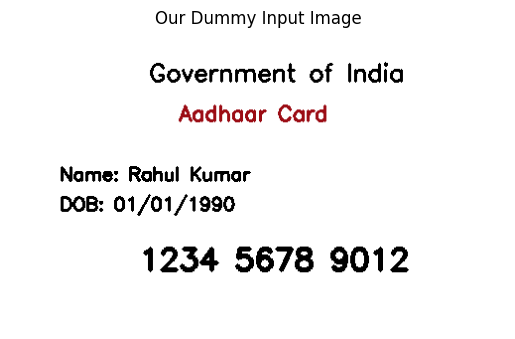

In [ ]:
# Since we don't want to upload real ID cards, let's create a fake one using code.

# Create a blank white image (Height: 300, Width: 500, 3 Color Channels)
image = np.full((300, 500, 3), 255, dtype=np.uint8)

# Add some text to look like an Aadhaar card
font = cv2.FONT_HERSHEY_SIMPLEX
cv2.putText(image, 'Government of India', (140, 50), font, 0.8, (0, 0, 0), 2)
cv2.putText(image, 'Aadhaar Card', (170, 90), font, 0.7, (20, 12, 155), 2)
cv2.putText(image, 'Name: Rahul Kumar', (50, 150), font, 0.6, (0, 0, 0), 2)
cv2.putText(image, 'DOB: 01/01/1990', (50, 180), font, 0.6, (0, 0, 0), 2)

# THE IMPORTANT PART: The Aadhaar Number
cv2.putText(image, '1234 5678 9012', (130, 240), font, 1, (0, 0, 0), 3)

# Save the image
cv2.imwrite('dummy_aadhaar.jpg', image)

# Show it
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Our Dummy Input Image')
plt.axis('off')
plt.show()

In [ ]:
# print("loading ocr model.....")
# reader = easyocr.Reader(['en'], gpu=False)
# image_path = 's.png'
# img = cv2.imread(image_path)

In [ ]:
import re
aadhaar_pattern=r"\d{4}\s\d{4}\s\d{4}"

In [ ]:
# 1. Setup
reader = easyocr.Reader(['en'], gpu=False)
image_path = 'ad.jpeg'
img = cv2.imread(image_path)
results = reader.readtext(image_path)

# The Aadhaar Regex Pattern
aadhaar_pattern = r"\d{4}\s\d{4}\s\d{4}"

# 2. The Logic Loop
found_any = False

for (bbox, text, prob) in results:
    if re.search(aadhaar_pattern, text):
        found_any = True
        print(f"[ALERT] Found Aadhaar Number: {text}")

        # --- A. Extract Full Box Coordinates ---
        # bbox = [Top-Left, Top-Right, Bottom-Right, Bottom-Left]
        (tl, tr, br, bl) = bbox

        x_start = int(tl[0])
        y_start = int(tl[1])
        x_end = int(br[0])
        y_end = int(br[1])

        # --- B. Calculate Partial Width ---
        total_width = x_end - x_start
        # We want to cover only the first 70% of the detected text
        mask_width = int(total_width * 0.64)

        # The new ending X-coordinate for our black box
        new_x_end = x_start + mask_width

        # --- C. Draw the Mask ---
        # Note: We use 'new_x_end' instead of the original 'x_end'
        img = cv2.rectangle(img, (x_start, y_start), (new_x_end, y_end), (255, 255, 255), -1)
        print(f"   -> Masking width: {mask_width} pixels (out of {total_width})")
        print("   -> Action: Masked first 8 digits!")
        box_height = y_end - y_start
        font_scale = box_height / 30.0
        cv2.putText(img, "XXXX XXXX", (x_start, y_end - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, font_scale, (0, 0, 0), 2)

        print("-> Professional Mask Applied!")

# 3. Show Result
if found_any:
    # Convert BGR (OpenCV) to RGB (Matplotlib)
    plt.figure(figsize=(10,6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    # plt.imshow(img)
    plt.title('Partially Masked Aadhaar')
    plt.axis('off')
    plt.show()
else:
    print("No Aadhaar pattern found to mask.")

No Aadhaar pattern found to mask.


In [ ]:
# import cv2
# import easyocr
# import re
# import matplotlib.pyplot as plt

# # 1. Setup
# reader = easyocr.Reader(['en'], gpu=False)
# image_path = 'adhar.jpeg'
# img = cv2.imread(image_path)
# results = reader.readtext(image_path)
# aadhaar_pattern = r"\d{4}\s\d{4}\s\d{4}"

# for (bbox, text, prob) in results:
#     if re.search(aadhaar_pattern, text):
#         # --- Coordinates ---
#         (tl, tr, br, bl) = bbox
#         x_start, y_start = int(tl[0]), int(tl[1])
#         x_end, y_end = int(br[0]), int(br[1])

#         # --- Logic: The 64% Cut ---
#         total_width = x_end - x_start
#         available_mask_width = int(total_width * 0.64)
#         new_x_end = x_start + available_mask_width

#         # 1. Erase (White Box)
#         cv2.rectangle(img, (x_start, y_start), (new_x_end, y_end), (255, 255, 255), -1)

#         # 2. DYNAMIC FONT SCALING
#         mask_text = "XXXX XXXX"
#         font = cv2.FONT_HERSHEY_SIMPLEX
#         initial_scale = (y_end - y_start) / 30.0

#         # --- The Alignment Logic ---
#         # This loop shrinks the text until it fits inside the mask_width
#         current_scale = initial_scale
#         while True:
#             # getTextSize returns (width, height), baseline
#             (w, h), _ = cv2.getTextSize(mask_text, font, current_scale, 2)
#             if w <= available_mask_width or current_scale < 0.1:
#                 break
#             current_scale -= 0.05  # Shrink slightly and try again

#         # 3. Write 'X's centered inside the white box
#         # x_start: stays the same
#         # y_position: we center it vertically
#         y_center = y_start + (y_end - y_start) // 2 + h // 2

#         cv2.putText(img, mask_text, (x_start, y_center),
#                     font, current_scale, (0, 0, 0), 2)

#         print(f"-> Auto-scaled text to {current_scale:.2f} to fit width!")

# # Show Result
# plt.figure(figsize=(10,6))
# plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
# plt.axis('off')
# plt.show()

In [1]:
import cv2
import easyocr
import re
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup
reader = easyocr.Reader(['en'], gpu=False)
# image_path = 'hh.jpeg'
img = cv2.imread(image_path)
results = reader.readtext(image_path)
aadhaar_pattern = r"\d{4}\s\d{4}\s\d{4}"

for (bbox, text, prob) in results:
    if re.search(aadhaar_pattern, text):
        # --- Coordinates ---
        (tl, tr, br, bl) = bbox
        x_start, y_start = int(tl[0]), int(tl[1])
        x_end, y_end = int(br[0]), int(br[1])

        # --- NEW STEP: BACKGROUND SAMPLING ---
        # We pick a pixel slightly above our text box (y_start - 5)
        # This should be the "clean" background color
        # IMPORTANT: img[y, x] is the order for pixels
        y_sample = max(0, y_start - 5)
        x_sample = x_start

        # Get the color. It returns a list like [B, G, R]
        # We convert to int so OpenCV doesn't complain later
        bg_color = [int(c) for c in img[y_sample, x_sample]]

        print(f"Sampled Background Color: {bg_color}")

        # --- Logic: The 64% Cut ---
        total_width = x_end - x_start
        available_mask_width = int(total_width * 0.64)
        new_x_end = x_start + available_mask_width

        # 1. Erase (Using sampled Color instead of pure White)
        cv2.rectangle(img, (x_start, y_start), (new_x_end, y_end), bg_color, -1)

        # 2. Seamless Text Styling
        # Lowercase 'x' and no spaces makes it look more integrated
        mask_text = "xxxxxxxx"
        font = cv2.FONT_HERSHEY_SIMPLEX
        box_height = y_end - y_start

        # Dynamic Scaling Loop
        current_scale = box_height / 35.0  # Slightly smaller starting guess for lowercase
        while True:
            (w, h), _ = cv2.getTextSize(mask_text, font, current_scale, 2)
            if w <= available_mask_width or current_scale < 0.1:
                break
            current_scale -= 0.05

        # Vertical Centering
        y_center = y_start + (box_height // 2) + (h // 2)

        # 3. Draw lowercase text
        # Tip: Use a slightly transparent-looking grey if you want,
        # but solid black (0,0,0) is fine for now.
        cv2.putText(img, mask_text, (x_start, y_center),
                    font, current_scale, (0, 0, 0), 2)

        print("-> Seamless Mask Applied!")

# Show Result
plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

ModuleNotFoundError: No module named 'easyocr'

In [ ]:
!pip install ultralytics

In [ ]:

# !pip install roboflow

# from roboflow import Roboflow
# rf = Roboflow(api_key="")
# project = rf.workspace("").project("")
# version = project.version(1)
# dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Adhar-Card-Detection-1 in yolov11:: 100%|██████████| 444/444 [00:00<00:00, 4766.97it/s]


In [ ]:
from ultralytics import YOLO

# 1. Load the small 'base' model to build upon
model = YOLO("yolo11n.pt")

# 2. Start the Training Process
model.train(
    data="/content/Adhar-Card-Detection-1/data.yaml", # Path to your DNA file
    epochs=50,      # Number of rounds to 'study' the data
    imgsz=640,      # Standard image resolution
    plots=True,     # Give us nice charts of our progress
    device=0,       # Use the GPU for speed
    degrees=90.0,    # 📐 Handles vertical/rotated cards like yours!
    mosaic=1.0,      # 🧩 Forces AI to find cards in messy/cluttered scenes (keyboard)
    fliplr=0.5,      # ↔️ Handles mirrored photos
    flipud=0.5,      # ↕️ Handles upside-down cards
    perspective=0.001 # 🔳 Handles tilted/angled card photos
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Adhar-Card-Detection-1/data.yaml, degrees=90.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, img

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e938c20edb0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
import easyocr
import re
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup
reader = easyocr.Reader(['en'])

def ultimate_aadhaar_engine(image_path, model):
    img = cv2.imread(image_path)
    if img is None:
        print("Error: Image not found.")
        return []

    h, w, _ = img.shape

    # --- STEP 1: Smart Image Preparation ---
    if h > w:
        print("Portrait detected. Rotating to Landscape for better AI visibility...")
        img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

    # --- STEP 2: Custom YOLO Detection ---
    results = model.predict(img, conf=0.3, verbose=False)
    verified_crops = []

    # --- STEP 3: Multi-Box Verification Loop ---
    for i, box in enumerate(results[0].boxes):
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        base_crop = img[y1:y2, x1:x2]

        print(f"Checking Box #{i+1} (Confidence: {box.conf[0]:.2f})...")

        # --- STEP 4: Orientation Correction (0, 90, 180, 270) ---
        found_valid = False
        for angle in [None, cv2.ROTATE_90_CLOCKWISE, cv2.ROTATE_180, cv2.ROTATE_90_COUNTERCLOCKWISE]:
            test_crop = base_crop.copy()
            if angle is not None:
                test_crop = cv2.rotate(test_crop, angle)

            # OCR Check (We need coordinates for masking, so detail=1)
            ocr_results = reader.readtext(test_crop)

            # --- STAGE 5: FIND & MASK AADHAAR ---
            masked_any = False
            for (bbox, text, prob) in ocr_results:
                # Check for the 12 digits (with or without spaces)
                clean_text = text.replace(" ", "")
                if re.search(r"\d{4}\s\d{4}\s\d{4}", text) or (len(clean_text) == 12 and clean_text.isdigit()):
                    print(f"✅ Aadhaar found in Box #{i+1} at angle {0 if angle is None else angle}")

                    (tl, tr, br, bl) = bbox
                    x_start, y_start = int(tl[0]), int(tl[1])
                    x_end, y_end = int(br[0]), int(br[1])

                    # --- NEW STEP: BACKGROUND SAMPLING (From the crop itself) ---
                    y_sample = max(0, y_start - 5)
                    x_sample = min(test_crop.shape[1]-1, x_start + 5)
                    bg_color = [int(c) for c in test_crop[y_sample, x_sample]]

                    # --- Logic: The 64% Cut ---
                    total_width = x_end - x_start
                    available_mask_width = int(total_width * 0.64)
                    new_x_end = x_start + available_mask_width

                    # 1. Erase (Using sampled Color)
                    cv2.rectangle(test_crop, (x_start, y_start), (new_x_end, y_end), bg_color, -1)

                    # 2. Seamless Text Styling
                    mask_text = "xxxxxxxx"
                    font = cv2.FONT_HERSHEY_SIMPLEX
                    box_height = y_end - y_start

                    # Dynamic Scaling
                    current_scale = box_height / 35.0
                    while True:
                        (tw, th), _ = cv2.getTextSize(mask_text, font, current_scale, 1)
                        if tw <= available_mask_width or current_scale < 0.1:
                            break
                        current_scale -= 0.05

                    # Vertical Centering logic
                    y_center = y_start + (box_height // 2) + (th // 2)

                    # 3. Draw lowercase text
                    cv2.putText(test_crop, mask_text, (x_start, y_center),
                                font, current_scale, (0, 0, 0), 1, cv2.LINE_AA)

                    print("-> Seamless Mask Applied!")
                    masked_any = True

            if masked_any:
                verified_crops.append(test_crop)
                found_valid = True
                break

        if not found_valid:
            print(f"❌ Box #{i+1} rejected (No valid Aadhaar number found).")

    return verified_crops

# EXECUTE
my_final_cards = ultimate_aadhaar_engine('hh.jpeg', model)

# 5. Display All Verified & Straightened Results
if my_final_cards:
    for i, card in enumerate(my_final_cards):
        plt.figure(figsize=(10, 6))
        plt.imshow(cv2.cvtColor(card, cv2.COLOR_BGR2RGB))
        plt.title(f"Verified & Protected Aadhaar #{i+1}")
        plt.axis('off')
        plt.show()
        cv2.imwrite(f'final_card_{i+1}.jpg', card)
else:
    print("No Aadhaar cards could be verified or masked.")

Portrait detected. Rotating to Landscape for better AI visibility...
Checking Box #1 (Confidence: 0.75)...
❌ Box #1 rejected (No valid Aadhaar number found).
Checking Box #2 (Confidence: 0.35)...
❌ Box #2 rejected (No valid Aadhaar number found).
No Aadhaar cards could be verified or masked.


In [ ]:
!pip install flask flask-cors easyocr opencv-python-headless


In [ ]:
import easyocr
import re
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup
reader = easyocr.Reader(['en'])

def ultimate_aadhaar_engine(image_path, model):
    img = cv2.imread(image_path)
    if img is None:
        print("Error: Image not found.")
        return []

    h, w, _ = img.shape

    # --- STEP 1: Smart Image Preparation ---
    if h > w:
        print("Portrait detected. Rotating to Landscape for better AI visibility...")
        img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

    # --- STEP 2: Custom YOLO Detection ---
    results = model.predict(img, conf=0.3, verbose=False)
    verified_crops = []

    # --- STEP 3: Multi-Box Verification Loop ---
    for i, box in enumerate(results[0].boxes):
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        base_crop = img[y1:y2, x1:x2]

        print(f"Checking Box #{i+1} (Confidence: {box.conf[0]:.2f})...")

        # --- STEP 4: Orientation Correction (0, 90, 180, 270) ---
        found_valid = False
        for angle in [None, cv2.ROTATE_90_CLOCKWISE, cv2.ROTATE_180, cv2.ROTATE_90_COUNTERCLOCKWISE]:
            test_crop = base_crop.copy()
            if angle is not None:
                test_crop = cv2.rotate(test_crop, angle)

            # OCR Check (We need coordinates for masking, so detail=1)
            ocr_results = reader.readtext(test_crop)

            # --- STAGE 5: FIND & MASK AADHAAR ---
            masked_any = False
            for (bbox, text, prob) in ocr_results:
                # Check for the 12 digits (with or without spaces)
                clean_text = text.replace(" ", "")
                if re.search(r"\d{4}\s\d{4}\s\d{4}", text) or (len(clean_text) == 12 and clean_text.isdigit()):
                    print(f"✅ Aadhaar found in Box #{i+1} at angle {0 if angle is None else angle}")

                    (tl, tr, br, bl) = bbox
                    x_start, y_start = int(tl[0]), int(tl[1])
                    x_end, y_end = int(br[0]), int(br[1])

                    # --- NEW STEP: BACKGROUND SAMPLING (From the crop itself) ---
                    y_sample = max(0, y_start - 5)
                    x_sample = min(test_crop.shape[1]-1, x_start + 5)
                    bg_color = [int(c) for c in test_crop[y_sample, x_sample]]

                    # --- Logic: The 64% Cut ---
                    total_width = x_end - x_start
                    available_mask_width = int(total_width * 0.64)
                    new_x_end = x_start + available_mask_width

                    # 1. Erase (Using sampled Color)
                    cv2.rectangle(test_crop, (x_start, y_start), (new_x_end, y_end), bg_color, -1)

                    # 2. Seamless Text Styling
                    mask_text = "xxxxxxxx"
                    font = cv2.FONT_HERSHEY_SIMPLEX
                    box_height = y_end - y_start

                    # Dynamic Scaling
                    current_scale = box_height / 35.0
                    while True:
                        (tw, th), _ = cv2.getTextSize(mask_text, font, current_scale, 1)
                        if tw <= available_mask_width or current_scale < 0.1:
                            break
                        current_scale -= 0.05

                    # Vertical Centering logic
                    y_center = y_start + (box_height // 2) + (th // 2)

                    # 3. Draw lowercase text
                    cv2.putText(test_crop, mask_text, (x_start, y_center),
                                font, current_scale, (0, 0, 0), 1, cv2.LINE_AA)

                    print("-> Seamless Mask Applied!")
                    masked_any = True

            if masked_any:
                verified_crops.append(test_crop)
                found_valid = True
                break

        if not found_valid:
            print(f"❌ Box #{i+1} rejected (No valid Aadhaar number found).")

    return verified_crops

# EXECUTE
my_final_cards = ultimate_aadhaar_engine('ad.jpeg', model)

# 5. Display All Verified & Straightened Results
if my_final_cards:
    for i, card in enumerate(my_final_cards):
        plt.figure(figsize=(10, 6))
        plt.imshow(cv2.cvtColor(card, cv2.COLOR_BGR2RGB))
        plt.title(f"Verified & Protected Aadhaar #{i+1}")
        plt.axis('off')
        plt.show()
        cv2.imwrite(f'final_card_{i+1}.png', card)
else:
    print("No Aadhaar cards could be verified or masked.")

Portrait detected. Rotating to Landscape for better AI visibility...
No Aadhaar cards could be verified or masked.


In [ ]:
import cv2
import easyocr
import re
import numpy as np
import base64
import io
import os
from flask import Flask, request, jsonify, render_template_string
from flask_cors import CORS
from ultralytics import YOLO
from PIL import Image

# Initialize Flask App
app = Flask(__name__)
CORS(app)

def preprocess_for_ocr(img):
    # 1. Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. THE FIX: Standard normalization stretches contrast globally,
    # instead of CLAHE which breaks contrast on dark backgrounds
    normalized = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX)

    # 3. Mild bilateral filter to remove noise without blurring edges
    denoised = cv2.bilateralFilter(normalized, 5, 50, 50)

    # 4. Convert back to BGR for EasyOCR
    return cv2.cvtColor(denoised, cv2.COLOR_GRAY2BGR)

# --- ENGINE INITIALIZATION ---
print("🚀 Initializing Aadhaar Shield Engines... (This may take a minute)")
try:
    # Use the requested YOLO model - assuming 'yolo11n.pt' or 'best.pt' if exists
    # Defaulting to yolo11n.pt as seen in previous apps
    model_path = "yolo26n.pt"
    model = YOLO(model_path)
    reader = easyocr.Reader(['en'], gpu=False)
    print(f"✅ Engines Loaded Successfully! using {model_path}")
except Exception as e:
    print(f"❌ Error loading engines: {e}")

def ultimate_aadhaar_engine(img):
    """
    PORTED LOGIC: Strictly maintaining all functional steps from the user's request.
    """
    if img is None:
        return None, False

    h, w, _ = img.shape
    processed_img = img.copy()

    # --- STEP 1: Smart Image Preparation ---
    if h > w:
        print("Portrait detected. Rotating to Landscape...")
        processed_img = cv2.rotate(processed_img, cv2.ROTATE_90_CLOCKWISE)
        h, w = processed_img.shape[0], processed_img.shape[1]

    # --- STEP 2: Custom YOLO Detection ---
    results = model.predict(processed_img, conf=0.3, verbose=False)

    masked_any_overall = False

    # --- STEP 3: Multi-Box Verification Loop ---
    for i, box in enumerate(results[0].boxes):
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        # Safety bounds
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(processed_img.shape[1], x2), min(processed_img.shape[0], y2)

        base_crop = processed_img[y1:y2, x1:x2]

        print(f"Checking Box #{i+1} (Confidence: {box.conf[0]:.2f})...")

        # --- STEP 4: Orientation Correction (0, 90, 180, 270) ---
        for angle in [None, cv2.ROTATE_90_CLOCKWISE, cv2.ROTATE_180, cv2.ROTATE_90_COUNTERCLOCKWISE]:
            test_crop = base_crop.copy()
            if angle is not None:
                test_crop = cv2.rotate(test_crop, angle)

            # Preprocess for OCR
            preprocessed_crop = preprocess_for_ocr(test_crop)

            # OCR Check
            ocr_results = reader.readtext(preprocessed_crop)

            # --- STAGE 5: FIND & MASK AADHAAR ---
            found_and_masked = False
            for (bbox, text, prob) in ocr_results:
                clean_text = text.replace(" ", "")
                if re.search(r"\d{4}\s\d{4}\s\d{4}", text) or (len(clean_text) == 12 and clean_text.isdigit()):
                    print(f"✅ Aadhaar found in Box #{i+1} at angle {0 if angle is None else angle}")

                    (tl, tr, br, bl) = bbox
                    mx_start, my_start = int(tl[0]), int(tl[1])
                    mx_end, my_end = int(br[0]), int(br[1])

                    # BACKGROUND SAMPLING
                    y_sample = max(0, my_start - 5)
                    x_sample = min(test_crop.shape[1]-1, mx_start + 5)
                    bg_color = [int(c) for c in test_crop[y_sample, x_sample]]

                    # MASKING LOGIC (64% Cut)
                    total_width = mx_end - mx_start
                    box_height = my_end - my_start
                    available_mask_width = int(total_width * 0.64)
                    new_x_end = mx_start + available_mask_width

                    cv2.rectangle(test_crop, (mx_start, my_start), (new_x_end, my_end), bg_color, -1)

                    mask_text = "xxxxxxxx"
                    font = cv2.FONT_HERSHEY_SIMPLEX
                    current_scale = box_height / 35.0
                    while True:
                        (tw, th), _ = cv2.getTextSize(mask_text, font, current_scale, 1)
                        if tw <= available_mask_width or current_scale < 0.1:
                            break
                        current_scale -= 0.05

                    y_center = my_start + (box_height // 2) + (th // 2)
                    cv2.putText(test_crop, mask_text, (mx_start, y_center),
                                font, current_scale, (0, 0, 0), 1, cv2.LINE_AA)

                    found_and_masked = True

            if found_and_masked:
                return test_crop, True

    # --- FINAL ROBUST FALLBACK (If YOLO fails or misses) ---
    print("⚠️ YOLO missed detection. Running full-image deep search...")
    # We rotate the whole image and check if OCR finds it
    for angle in [None, cv2.ROTATE_90_CLOCKWISE, cv2.ROTATE_180, cv2.ROTATE_90_COUNTERCLOCKWISE]:
        fallback_img = processed_img.copy()
        if angle is not None:
            fallback_img = cv2.rotate(fallback_img, angle)

        preprocessed_fallback = preprocess_for_ocr(fallback_img)
        ocr_results = reader.readtext(preprocessed_fallback)
        found_and_masked = False

        for (bbox, text, prob) in ocr_results:
            clean_text = text.replace(" ", "")
            if re.search(r"\d{4}\s\d{4}\s\d{4}", text) or (len(clean_text) == 12 and clean_text.isdigit()):
                print(f"✅ Aadhaar found in Fallback Mode at angle {0 if angle is None else angle}")
                (tl, tr, br, bl) = bbox
                mx_start, my_start = int(tl[0]), int(tl[1])
                mx_end, my_end = int(br[0]), int(br[1])
                y_sample = max(0, my_start - 5)
                x_sample = min(fallback_img.shape[1]-1, mx_start + 5)
                bg_color = [int(c) for c in fallback_img[y_sample, x_sample]]
                total_width = mx_end - mx_start
                box_height = my_end - my_start
                available_mask_width = int(total_width * 0.64)
                new_x_end = mx_start + available_mask_width
                cv2.rectangle(fallback_img, (mx_start, my_start), (new_x_end, my_end), bg_color, -1)
                mask_text = "xxxxxxxx"
                current_scale = box_height / 35.0
                while True:
                    (tw, th), _ = cv2.getTextSize(mask_text, cv2.FONT_HERSHEY_SIMPLEX, current_scale, 1)
                    if tw <= available_mask_width or current_scale < 0.1: break
                    current_scale -= 0.05
                y_center = my_start + (box_height // 2) + (th // 2)
                cv2.putText(fallback_img, mask_text, (mx_start, y_center), cv2.FONT_HERSHEY_SIMPLEX, current_scale, (0, 0, 0), 1, cv2.LINE_AA)
                found_and_masked = True

        if found_and_masked:
            return fallback_img, True

    return processed_img, False


# --- PREVENT ERRORS FOR MISSING ROUTE ---
@app.route('/mask', methods=['POST'])
def mask_image():
    if 'image' not in request.files:
        return jsonify({"error": "No image uploaded"}), 400

    file = request.files['image']
    nparr = np.frombuffer(file.read(), np.uint8)
    img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

    if img is None:
        return jsonify({"error": "Invalid image"}), 400

    processed_img, found = ultimate_aadhaar_engine(img)

    _, buffer = cv2.imencode('.jpg', processed_img)
    img_base64 = base64.b64encode(buffer).decode('utf-8')

    return jsonify({
        "status": "success" if found else "no_aadhaar_found",
        "image": img_base64
    })

# --- STUNNING PASTEL UI ---
HTML_TEMPLATE = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Aadhaar Shield | Premium Protection</title>
    <link href="https://fonts.googleapis.com/css2?family=Outfit:wght@300;400;600&display=swap" rel="stylesheet">
    <style>
        :root {
            --p-blue: #D4F1F4;
            --p-pink: #FAD0C4;
            --p-purple: #E2E2E2;
            --accent: #A18CD1;
            --text: #2D3436;
            --glass: rgba(255, 255, 255, 0.75);
        }

        * { margin: 0; padding: 0; box-sizing: border-box; }

        body {
            font-family: 'Outfit', sans-serif;
            background: linear-gradient(120deg, #fdfbfb 0%, #ebedee 100%);
            color: var(--text);
            min-height: 100vh;
            display: flex;
            justify-content: center;
            align-items: center;
            padding: 20px;
        }

        .decorative-blob {
            position: fixed;
            z-index: -1;
            filter: blur(80px);
            opacity: 0.5;
            border-radius: 50%;
        }

        .blob-1 { width: 400px; height: 400px; background: var(--p-pink); top: -100px; right: -100px; }
        .blob-2 { width: 300px; height: 300px; background: var(--p-blue); bottom: -50px; left: -50px; }

        .app-container {
            width: 100%;
            max-width: 900px;
            background: var(--glass);
            backdrop-filter: blur(20px);
            border: 1px solid rgba(255, 255, 255, 0.5);
            border-radius: 40px;
            padding: 50px;
            box-shadow: 0 25px 50px -12px rgba(0, 0, 0, 0.08);
            text-align: center;
        }

        header { margin-bottom: 40px; }
        header h1 {
            font-size: 3rem;
            font-weight: 600;
            background: linear-gradient(to right, #6A11CB 0%, #2575FC 100%);
            -webkit-background-clip: text;
            -webkit-fill-color: transparent;
            margin-bottom: 10px;
        }
        header p { color: #636E72; font-size: 1.1rem; opacity: 0.8; }

        .upload-wrapper {
            border: 2px dashed #A18CD1;
            border-radius: 30px;
            padding: 60px 20px;
            cursor: pointer;
            transition: all 0.4s cubic-bezier(0.175, 0.885, 0.32, 1.275);
            background: rgba(161, 140, 209, 0.03);
            margin-bottom: 30px;
        }

        .upload-wrapper:hover {
            transform: translateY(-5px);
            background: rgba(161, 140, 209, 0.08);
            border-color: #8E44AD;
        }

        .upload-icon { font-size: 70px; margin-bottom: 15px; display: block; }

        .btn {
            background: linear-gradient(135deg, #A18CD1 0%, #FBC2EB 100%);
            color: white;
            border: none;
            padding: 16px 45px;
            border-radius: 50px;
            font-weight: 600;
            font-size: 1.1rem;
            cursor: pointer;
            box-shadow: 0 10px 20px rgba(161, 140, 209, 0.3);
            transition: all 0.3s ease;
            display: inline-flex;
            align-items: center;
            gap: 10px;
        }

        .btn:hover {
            transform: scale(1.05);
            box-shadow: 0 15px 30px rgba(161, 140, 209, 0.4);
        }

        #resultArea {
            display: none;
            margin-top: 50px;
            animation: slideUp 0.8s cubic-bezier(0.23, 1, 0.32, 1);
        }

        @keyframes slideUp {
            from { opacity: 0; transform: translateY(40px); }
            to { opacity: 1; transform: translateY(0); }
        }

        .image-preview-grid {
            display: grid;
            grid-template-columns: 1fr 1fr;
            gap: 30px;
            margin-top: 30px;
        }

        .preview-card {
            background: white;
            padding: 15px;
            border-radius: 25px;
            box-shadow: 0 10px 25px rgba(0,0,0,0.03);
        }

        .preview-card h4 {
            font-size: 0.9rem;
            text-transform: uppercase;
            letter-spacing: 1px;
            color: #B2BEC3;
            margin-bottom: 15px;
        }

        .preview-card img {
            width: 100%;
            border-radius: 15px;
            display: block;
        }

        .loader {
            display: none;
            margin: 30px auto;
            border: 4px solid #f3f3f3;
            border-top: 4px solid #A18CD1;
            border-radius: 50%;
            width: 45px;
            height: 45px;
            animation: spin 1s linear infinite;
        }

        @keyframes spin { 0% { transform: rotate(0deg); } 100% { transform: rotate(360deg); } }

        .download-footer { margin-top: 30px; }

        footer { margin-top: 40px; color: #B2BEC3; font-size: 0.9rem; font-weight: 300; }
    </style>
</head>
<body>
    <div class="decorative-blob blob-1"></div>
    <div class="decorative-blob blob-2"></div>

    <div class="app-container">
        <header>
            <h1>Aadhaar Shield</h1>
            <p>Your Privacy, Protected with AI Elegance</p>
        </header>

        <div class="upload-wrapper" id="dropZone" onclick="document.getElementById('fileInp').click()">
            <span class="upload-icon">🪄</span>
            <h3 style="color:#6C5CE7">Select Aadhaar Photo</h3>
            <p>Drag & drop your JPG/PNG here</p>
            <input type="file" id="fileInp" hidden accept="image/*">
            <button class="btn" style="margin-top:20px">Browse Files</button>
        </div>

        <div class="loader" id="loader"></div>

        <div id="resultArea">
            <div class="image-preview-grid">
                <div class="preview-card">
                    <h4>Original Input</h4>
                    <img id="origImg">
                </div>
                <div class="preview-card">
                    <h4>Shielded Result</h4>
                    <img id="maskedImg">
                </div>
            </div>
            <div class="download-footer">
                <button class="btn" id="downloadBtn">
                    <span>✨ Download Shielded Card</span>
                </button>
                <p style="margin-top:15px; font-size:0.8rem; color:#A18CD1">Masking applied precisely at the first 8 digits.</p>
            </div>
        </div>

        <footer>
            Crafted for maximum security & minimal effort
        </footer>
    </div>

    <script>
        const fileInp = document.getElementById('fileInp');
        const loader = document.getElementById('loader');
        const resultArea = document.getElementById('resultArea');
        const dropZone = document.getElementById('dropZone');

        fileInp.onchange = async (e) => {
            const file = e.target.files[0];
            if(!file) return;
            processImage(file);
        };

        // Drag and Drop
        dropZone.ondragover = (e) => { e.preventDefault(); dropZone.style.borderColor = '#8E44AD'; };
        dropZone.ondragleave = () => { dropZone.style.borderColor = '#A18CD1'; };
        dropZone.ondrop = (e) => {
            e.preventDefault();
            const file = e.dataTransfer.files[0];
            if(file) processImage(file);
        };

        async function processImage(file) {
            // Preview Original
            const r = new FileReader();
            r.onload = (e) => document.getElementById('origImg').src = e.target.result;
            r.readAsDataURL(file);

            // UI State
            loader.style.display = 'block';
            resultArea.style.display = 'none';

            const fd = new FormData();
            fd.append('image', file);

            try {
                const res = await fetch('/mask', { method: 'POST', body: fd });
                const data = await res.json();

                if(data.status === 'success') {
                    const maskedSource = 'data:image/jpeg;base64,' + data.image;
                    document.getElementById('maskedImg').src = maskedSource;
                    resultArea.style.display = 'block';

                    document.getElementById('downloadBtn').onclick = () => {
                        const lnk = document.createElement('a');
                        lnk.href = maskedSource;
                        lnk.download = 'shielded_aadhaar.jpg';
                        lnk.click();
                    };
                } else if(data.status === 'no_aadhaar_found') {
                    alert('We could not find a clear Aadhaar number in this photo. Please ensure the card is well-lit and clearly visible.');
                } else {
                    alert('Error processing image. Please try another file.');
                }
            } catch(err) {
                alert('Connection to AI engine failed. Ensure server is running.');
            } finally {
                loader.style.display = 'none';
            }
        }
    </script>
</body>
</html>
"""

@app.route('/')
def home():
    return render_template_string(HTML_TEMPLATE)

if __name__ == '__main__':
    # --- GOOGLE COLAB SUPPORT ---
    try:
        from google.colab.output import eval_js
        print("\n" + "🚀" * 15)
        print("RUNNING IN GOOGLE COLAB DETECTED")
        print("Click the link below to open your Aadhaar Shield:")
        print(eval_js("google.colab.kernel.proxyPort(5000)"))
        print("🚀" * 15 + "\n")
    except ImportError:
        print("\n" + " ✨ " * 10)
        print("Welcome to Aadhaar Shield v2.0")
        print("Open: http://127.0.0.1:5000")
        print(" ✨ " * 10 + "\n")

    app.run(host='0.0.0.0', port=5000, debug=False)


🚀 Initializing Aadhaar Shield Engines... (This may take a minute)
✅ Engines Loaded Successfully! using yolo26n.pt

🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀
RUNNING IN GOOGLE COLAB DETECTED
Click the link below to open your Aadhaar Shield:
https://5000-gpu-t4-s-kkb-usw1b0-2dgjysc6wvxj5-b.us-west1-0.prod.colab.dev
🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [15/Mar/2026 02:14:59] "GET / HTTP/1.1" 200 -


Portrait detected. Rotating to Landscape...
⚠️ YOLO missed detection. Running full-image deep search...


INFO:werkzeug:127.0.0.1 - - [15/Mar/2026 02:16:35] "POST /mask HTTP/1.1" 200 -


Checking Box #1 (Confidence: 0.65)...
⚠️ YOLO missed detection. Running full-image deep search...


...

✅ Aadhaar found in Fallback Mode at angle 0


INFO:werkzeug:127.0.0.1 - - [15/Mar/2026 02:17:06] "GET / HTTP/1.1" 200 -


Portrait detected. Rotating to Landscape...
⚠️ YOLO missed detection. Running full-image deep search...


INFO:werkzeug:127.0.0.1 - - [15/Mar/2026 02:18:31] "POST /mask HTTP/1.1" 200 -


✅ Aadhaar found in Fallback Mode at angle 2
✅ Aadhaar found in Fallback Mode at angle 2
